In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.files import get_latest_file
from pathlib import Path
import missingno as msno
from statsmodels.tsa.stattools import adfuller
from src.utils.clean_data import remove_cols

In [ ]:
import keras
import tensorflow as tf

class BlockDiagonal(keras.layers.Layer):

    """
    Block diagonal layer that takes an entire feature vector of dimension 
    input_dim and splits it into num_heads each with dimension 
    head_dim = input_dim // num_heads. Then, each head performs a linear
    projection along the head_dim outputing a tensor of shape 
    (batch, num_heads, head_dim) 
    """

    def __init__(
            self, 
            num_heads,
            units,
            **kwargs
        ):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.units = units

    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.head_dim = input_dim // self.num_heads

        self.W = self.add_weight( 
            shape=(self.num_heads, self.head_dim, self.head_dim)
        )

        self.b = self.add_weight(
            shape=(self.num_heads, self.head_dim)
        )

    def call(self, x):
        # x comes in the shape (batch, input_dim) but we want (batch, num_heads, head_dim)
        batch = tf.shape(x)[0]

        # Partition the input
        x = tf.reshape(x, shape=(batch, self.num_heads, self.head_dim))
        
        # Einstein sum as an efficient alternative to Block diagonal matrix
        #  multiplication. Equivalent to multiplying each weight matrix by the
        #  corresponding input subset (along dimension j)
        # Doing this for the whole batch results in shape 
        # (batch, num_heads, head_dim). Bias broadcasts across batch
        y = tf.einsum("hij,bhj->bhi", self.W, x) + self.b

        return y
    
class MultiHeadSLSTMCell(keras.layers.Layer):
    def __init__(
            self, 
            units, 
            kernel_initializer="glorot_uniform", 
            kernel_regularizer=None,
            **kwargs
        ):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = (self.units, self.units, self.units, self.units)

        self.kernel_initializer = keras.initializers.get(kernel_initializer)

        self.kernel_regularizer = keras.regularizers.get(kernel_regularizer)

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Weights for input and hidden state
        self.kernel = self.add_weight(shape=(input_dim, 4 * self.units),
                                 initializer=self.kernel_initializer,
                                 regularizer=self.kernel_regularizer,
                                 name='kernel')
        self.recurrent_kernel = self.add_weight(shape=(self.units, 4 * self.units),
                                 initializer='orthogonal',
                                 name='recurrent_kernel')
        self.biases = self.add_weight(shape=(4 * self.units,),
                                 initializer='zeros',
                                 name='biases')
        self.built = True
    
    def call(self, inputs, states):
        h_prev, c_prev, n_prev, m_prev = states 

        z = tf.matmul(inputs, self.kernel) + tf.matmul(h_prev, self.recurrent_kernel) + self.biases

        i_candidate, f_candidate, z_candidate, o_candidate = tf.split(z, num_or_size_splits=4, axis=1)

        logfplusm = tf.ops.log_sigmoid(f_candidate) + m_prev

        m = tf.cond(
            tf.reduce_all(tf.equal(n_prev, 0.0)),
            lambda: i_candidate,
            lambda: tf.maximum(i_candidate, logfplusm),
        )
        
        # usual output gate and cell state candidate
        o = tf.ops.sigmoid(o_candidate)
        z = tf.ops.tanh(z_candidate)

        # Stabilized input and foreget gates
        i = tf.ops.minimum(tf.ops.exp(i_candidate - m), tf.ops.ones_like(i_candidate))
        f = tf.ops.minimum(tf.ops.exp(logfplusm - m), tf.ops.ones_like(i_candidate))
        
        c = f * c_prev + i * z
        n = f * n_prev + i
        h = o * c / n
        
        return h, [h, c, n, m]
    
    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "kernel_initializer": self.kernel_initializer,
                "kernel_regularizer": self.kernel_regularizer
            }
        )
        return config

def generate_data(n_samples, num_heads=2,n_features=4):

    assert n_features % num_heads == 0
    np.random.seed(1)
    head_dim = n_features // num_heads
    X = np.random.randn(n_samples, n_features).reshape(n_samples, num_heads, head_dim)
    W_true = np.ones((num_heads, head_dim))
    
    y = np.einsum('nhi,hi->n', X, W_true)

    return X, y


### Test block diagonal layer 

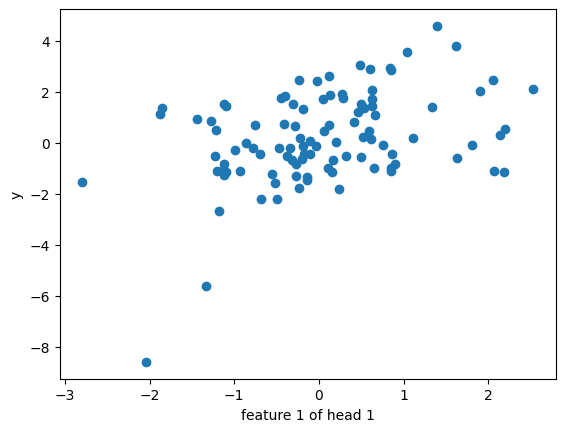

In [9]:
import matplotlib.pyplot as plt

X, y = generate_data(n_samples=100)

plt.scatter(X[:,0, 0], y)
plt.xlabel('feature 1 of head 1')
plt.ylabel('y')
plt.show()

In [17]:
# Make a simple neural network
model = keras.models.Sequential()
model.add(BlockDiagonal(num_heads=2, units=1))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1))
model.compile(optimizer='sgd', loss='mse')

model.fit(X.reshape(X.shape[0], -1), y, epochs=100, batch_size=4)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7575  
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8347 
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9093 
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3513 
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0988 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0215 
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042 
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.5802e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2621e-04 
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.9720e-05 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6855e-05 
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.8880e-06 
Epoch 13/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4082e-06 
Epoch 14/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1487e-07 
Epoch 15/100
25/25 ━━━━━━━━━━

In [19]:
y_pred = model.predict(X.reshape(X.shape[0], -1))

print(f"MSE: {np.sum(y_pred - y)**2}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
MSE: 5.844684498420061e-10


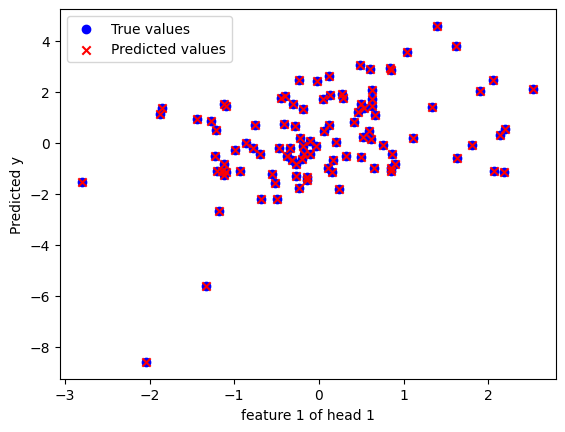

In [23]:
plt.scatter(X[:,0, 0], y, c='blue', label='True values')
plt.scatter(X[:,0, 0], y_pred, c='red', marker='x', label='Predicted values')
plt.xlabel('feature 1 of head 1')
plt.ylabel('Predicted y')
plt.legend()
plt.show()

In [1]:
from src.preprocessing.prepare_quantile_data import prepare_quantile_data
from operator import itemgetter
target_path = './data/processed/us_4q_fred_y.parquet'
input_paths = ['./data/processed/us_4q_fred_x.parquet']

# Prepare data (including RNN sequences)
non_rnn_data, rnn_data, meta_data = prepare_quantile_data(
    target=0,
    time_steps=12,
    targets_path=target_path,
    input_paths=input_paths,
    start_date='1961-01-01',
    train_cutoff_year=1997,
    n_quantiles=5,
    val_years=5
)

# Extract RNN data
(
    mq_y_train_rnn, mq_y_val_rnn, mq_y_train_full_rnn,
    X_train_rnn, X_val_rnn, X_train_full_rnn, X_test_rnn,
) = itemgetter(
    'mq_y_train_rnn', 'mq_y_val_rnn', 'mq_y_train_full_rnn',
    'X_train_rnn', 'X_val_rnn', 'X_train_full_rnn', 'X_test_rnn',
)(rnn_data)

Train: 1961-01-01 to 1992-12-01 00:00:00
Validation: 1993-01-01 00:00:00 to 1997-12-01 00:00:00
Test: 1998-01-01 00:00:00 to 1998-12-01 00:00:00


In [2]:
from src.train.models import build_dmq_v0

dmq_xlstm = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    recurrent_layer_type='xlstm'
)

dmq_xlstm.summary()

ValueError: Unrecognized keyword arguments passed to sLSTM: {'kernel_regularizer': <keras.src.regularizers.regularizers.L1L2 object at 0x000001D582F114C0>, 'kernel_initializer': <keras.src.initializers.random_initializers.GlorotUniform object at 0x000001D5220FA2D0>}